In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def log_likelihood(vr, mu, sig, e_vr=0):
    total_var = sig**2 + e_vr**2
    single_logp = -0.5 * (np.log(2 * np.pi * total_var) + (vr - mu) ** 2 / total_var)
    return np.sum(single_logp)

In [3]:
def metropolis(vr_data, e_vr=0, n_samples=50000, mu_init=0, sig_init=1,clip=10000):
    count_accepted=0
    chain = np.zeros((n_samples, 3))
    logL0 = log_likelihood(vr_data, mu_init, sig_init, e_vr)
    chain[0] = [mu_init, sig_init, logL0]

    for i in range(1, n_samples):
        mu_current, sig_current, logL_current = chain[i-1]
        mu_proposal = np.random.normal(mu_current, 5)
        sig_proposal = np.random.normal(sig_current, 5)
        if sig_proposal <= 0:
            chain[i] = [mu_current, sig_current, logL_current]
            continue
        
        logL_prop = log_likelihood(vr_data, mu_proposal, sig_proposal, e_vr)
        accept_alpha = min(1, np.exp(logL_prop - logL_current))

        a = np.random.rand()
        if a < accept_alpha:
            count_accepted+=1
            chain[i] = [mu_proposal, sig_proposal, logL_prop]
        else:
            chain[i] = [mu_current, sig_current, logL_current]

    return chain[clip:]

In [19]:
def plot_mdyn_dist(Mdyn_samples, bins=200, figsize=(10, 5), name=""):
    log_mdyn = np.log10(Mdyn_samples)
    p16, p50, p84 = np.percentile(log_mdyn, [16, 50, 84])
    
    plt.figure(figsize=figsize)
    plt.hist(log_mdyn, bins=bins, alpha=0.7, density=True, color="#3ef23b", label=r"$P(\log_{10}M_\mathrm{dyn})$")
    plt.axvline(p50, color="black", linestyle="-", lw=2, label=f"Median = {p50:.2f}")
    plt.axvline(p16, color="black", linestyle="--", lw=1.5, alpha=0.6)
    plt.axvline(p84, color="black", linestyle="--", lw=1.5, alpha=0.6)
    
    plt.xlabel(r"$\log_{10}(M_\mathrm{dyn}/M_\odot)$", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.title(f"Posterior Distribution of Dynamical Mass({name})", fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"log10(M_dyn/M☉) 1σ区间：{p16:.2f} ~ {p50:.2f} ~ {p84:.2f}")
    print(f"形式：{p50:.2f} +{p84-p50:.2f} -{p50-p16:.2f}")

C:\Users\32166\AppData\Local\Temp\ipykernel_18276\1580211002.py:16: RuntimeWarning: overflow encountered in exp
  accept_alpha = min(1, np.exp(logL_prop - logL_current))


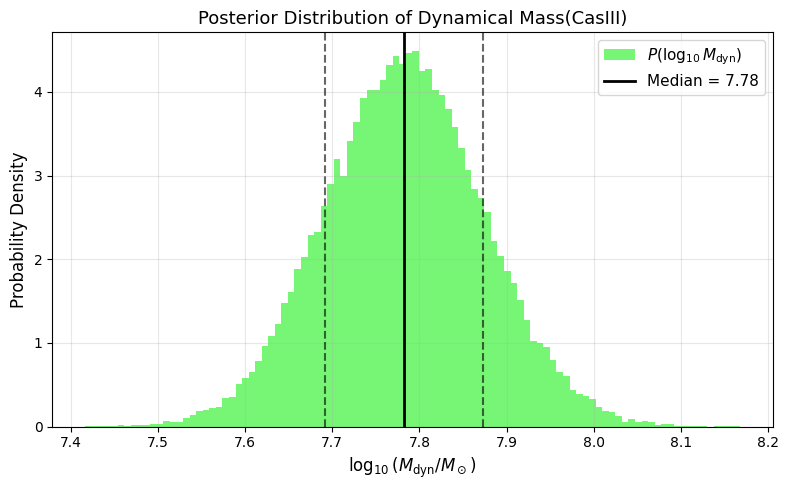

log10(M_dyn/M☉) 1σ区间：7.69 ~ 7.78 ~ 7.87
形式：7.78 +0.09 -0.09


In [20]:
df=pd.read_csv('data/cas3.csv')
vr_data = df["vr"].values
e_vr=df["e_vr"].values

chain = metropolis(vr_data, e_vr=e_vr, n_samples=50000, mu_init=-350, sig_init=5, clip=10000)
sigma_chain = chain[:, 1]
rh_chain = np.loadtxt("data/rh_chains/CasIII_rh_chain.txt")

mu_mean = 24.45
mu_std = 0.14
N_mc = 50000

Mdyn_samples = np.zeros(N_mc)

for i in range(N_mc):
    mu_sample = np.random.normal(mu_mean, mu_std)
    sigma_sample = np.random.choice(sigma_chain)
    rh_sample = np.random.choice(rh_chain)

    D_pc = 10**((mu_sample+5)/5)
    rad_arcmin = rh_sample * np.pi / (180 * 60)
    rh_pc = D_pc * np.tan(rad_arcmin)
    Mdyn_samples[i] = 580 * (sigma_sample ** 2) * rh_pc

plot_mdyn_dist(Mdyn_samples, bins=100, figsize=(8, 5),name="CasIII")

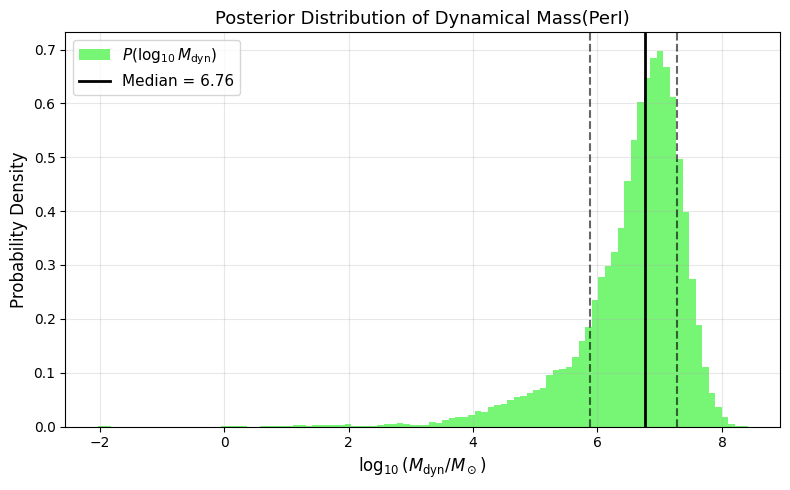

log10(M_dyn/M☉) 1σ区间：5.87 ~ 6.76 ~ 7.27
形式：6.76 +0.52 -0.88


In [24]:
df=pd.read_csv('data/per1.csv')
vr_data = df["vr"].values
e_vr=df["e_vr"].values

chain = metropolis(vr_data, e_vr=e_vr, n_samples=50000, mu_init=-300, sig_init=8, clip=10000)
sigma_chain = chain[:, 1]
rh_chain = np.loadtxt("data/rh_chains/PerI_rh_chain.txt")

mu_mean = 24.49
mu_std = 0.18
N_mc = 50000

Mdyn_samples = np.zeros(N_mc)

for i in range(N_mc):
    mu_sample = np.random.normal(mu_mean, mu_std)
    sigma_sample = np.random.choice(sigma_chain)
    rh_sample = np.random.choice(rh_chain)

    D_pc = 10**((mu_sample+5)/5)
    rad_arcmin = rh_sample * np.pi / (180 * 60)
    rh_pc = D_pc * np.tan(rad_arcmin)
    Mdyn_samples[i] = 580 * (sigma_sample ** 2) * rh_pc

plot_mdyn_dist(Mdyn_samples, bins=100, figsize=(8, 5),name="PerI")